# Pharos Adapter Performance

Live report for adapter checkpoint timing in the ifxdev ArangoDB `pharos` database. Re-run the notebook after a build to refresh the tables and plots from `metadata_store`.

In [ ]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPORT_DIR = REPO_ROOT / "reports/pharos adapter performance"
GRAPH_DATABASE = "pharos"
CREDENTIALS_PATH = REPO_ROOT / "src/use_cases/secrets/ifxdev_arangodb.yaml"

# Keep this live-only by default. Set to True when you explicitly want a fresh CSV/SVG snapshot.
SAVE_ARTIFACTS = False
OUTPUT_DIR = REPORT_DIR

# None means include every ETL checkpoint in metadata_store. Use this list to focus the report.
RUN_IDS = [
    "./src/use_cases/pharos/pharos.yaml",
    "./src/use_cases/pharos/pharos_aql_post.yaml",
]

REPO_ROOT

In [ ]:
from datetime import datetime, timezone
import io
import math
import re

import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import SVG, display

from src.shared.db_credentials import DBCredentials
from src.shared.arango_adapter import ArangoAdapter

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.8,
    "font.size": 10,
})

In [ ]:
def parse_dt(value):
    if not value:
        return pd.NaT
    return pd.to_datetime(value, utc=True, errors="coerce")


def format_duration(seconds):
    if pd.isna(seconds):
        return ""
    seconds = int(round(float(seconds)))
    days, seconds = divmod(seconds, 86400)
    hours, seconds = divmod(seconds, 3600)
    minutes, seconds = divmod(seconds, 60)
    parts = []
    if days:
        parts.append(f"{days}d")
    if hours or days:
        parts.append(f"{hours}h")
    if minutes or hours or days:
        parts.append(f"{minutes}m")
    parts.append(f"{seconds}s")
    return " ".join(parts)


def short_adapter_name(name):
    base = re.sub(r"Adapter\b", "", name.split("(", 1)[0]).strip()
    return base[:32]


def fetch_checkpoints():
    creds = DBCredentials.from_yaml(yaml.safe_load(CREDENTIALS_PATH.read_text()))
    adapter = ArangoAdapter(creds, GRAPH_DATABASE)
    query = """
    FOR d IN metadata_store
        FILTER d.type == "etl_checkpoint"
        SORT d.last_updated ASC
        RETURN d
    """
    checkpoints = adapter.runQuery(query)
    if RUN_IDS is not None:
        wanted = set(RUN_IDS)
        checkpoints = [checkpoint for checkpoint in checkpoints if checkpoint.get("run_id") in wanted]
    return checkpoints


def checkpoint_rows(checkpoints):
    rows = []
    for checkpoint in checkpoints:
        run_id = checkpoint.get("run_id")
        for adapter_name, metadata in (checkpoint.get("adapters") or {}).items():
            started_at = parse_dt(metadata.get("started_at"))
            completed_at = parse_dt(metadata.get("completed_at"))
            failed_at = parse_dt(metadata.get("failed_at"))
            ended_at = completed_at if pd.notna(completed_at) else failed_at
            elapsed_seconds = (ended_at - started_at).total_seconds() if pd.notna(started_at) and pd.notna(ended_at) else np.nan
            records_written = metadata.get("records_written") or 0
            rows.append({
                "run_id": run_id,
                "checkpoint_last_updated": checkpoint.get("last_updated"),
                "name": adapter_name,
                "short_name": short_adapter_name(adapter_name),
                "status": metadata.get("status", "unknown"),
                "adapter_position": metadata.get("adapter_position"),
                "adapter_total": metadata.get("adapter_total"),
                "records_written": records_written,
                "started_at": started_at,
                "completed_at": completed_at,
                "failed_at": failed_at,
                "elapsed_seconds": elapsed_seconds,
                "elapsed_minutes": elapsed_seconds / 60 if not math.isnan(elapsed_seconds) else np.nan,
                "records_per_second": records_written / elapsed_seconds if elapsed_seconds and elapsed_seconds > 0 else np.nan,
            })
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No checkpoint adapter rows found for the configured RUN_IDS.")
    return df.sort_values(["run_id", "adapter_position", "name"], na_position="last").reset_index(drop=True)


checkpoints = fetch_checkpoints()
df = checkpoint_rows(checkpoints)
df.head()

In [ ]:
completed = df[(df["status"] == "completed") & (df["elapsed_seconds"] > 0)].copy()
fit_df = completed[(completed["records_written"] > 0) & (completed["elapsed_minutes"] > 0)].copy()

if len(fit_df) >= 2:
    x = np.log10(fit_df["records_written"].astype(float))
    y = np.log10(fit_df["elapsed_minutes"].astype(float))
    slope, intercept = np.polyfit(x, y, 1)
    completed.loc[fit_df.index, "predicted_elapsed_minutes"] = 10 ** (intercept + slope * x)
    completed.loc[fit_df.index, "log10_residual"] = y - (intercept + slope * x)
    completed.loc[fit_df.index, "slowdown_factor_vs_trend"] = 10 ** completed.loc[fit_df.index, "log10_residual"]
else:
    slope = intercept = np.nan
    completed["predicted_elapsed_minutes"] = np.nan
    completed["log10_residual"] = np.nan
    completed["slowdown_factor_vs_trend"] = np.nan

summary = (
    completed.groupby("run_id", dropna=False)
    .agg(
        adapters=("name", "count"),
        records_written=("records_written", "sum"),
        started_at=("started_at", "min"),
        completed_at=("completed_at", "max"),
        adapter_elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
)
summary["wall_seconds"] = (summary["completed_at"] - summary["started_at"]).dt.total_seconds()
summary["adapter_elapsed"] = summary["adapter_elapsed_seconds"].map(format_duration)
summary["wall_time"] = summary["wall_seconds"].map(format_duration)
summary[["run_id", "adapters", "records_written", "started_at", "completed_at", "wall_time", "adapter_elapsed"]]

In [ ]:
top_slowest = completed.sort_values("elapsed_seconds", ascending=False).head(15).copy()
top_slowest["elapsed"] = top_slowest["elapsed_seconds"].map(format_duration)
top_slowest[[
    "run_id",
    "adapter_position",
    "short_name",
    "records_written",
    "elapsed",
    "records_per_second",
    "slowdown_factor_vs_trend",
]]

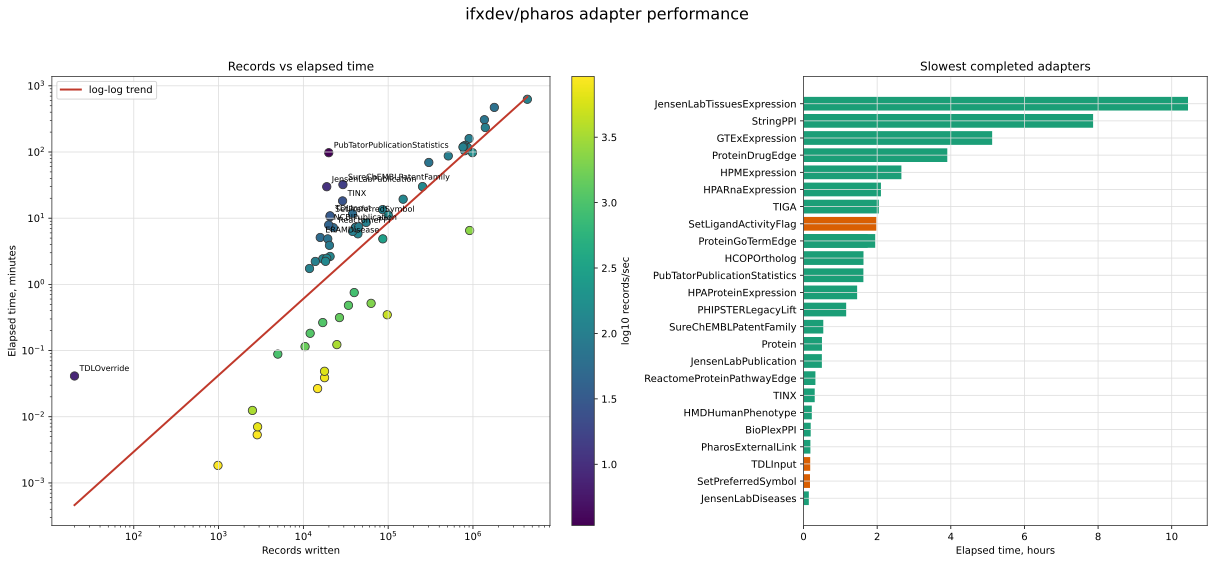

In [12]:
plot_df = completed[(completed["records_written"] > 0) & (completed["elapsed_minutes"] > 0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 8), gridspec_kw={"width_ratios": [1.35, 1]})
fig.suptitle("ifxdev/pharos adapter performance", fontsize=16, y=0.98)

ax = axes[0]
scatter = ax.scatter(
    plot_df["records_written"],
    plot_df["elapsed_minutes"],
    c=np.log10(plot_df["records_per_second"].clip(lower=1e-9)),
    cmap="viridis",
    s=70,
    edgecolor="#333333",
    linewidth=0.8,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Records written")
ax.set_ylabel("Elapsed time, minutes")
ax.set_title("Records vs elapsed time")

if len(fit_df) >= 2:
    xs = np.logspace(np.log10(plot_df["records_written"].min()), np.log10(plot_df["records_written"].max()), 200)
    ys = 10 ** (intercept + slope * np.log10(xs))
    ax.plot(xs, ys, color="#c0392b", linewidth=2, label="log-log trend")
    ax.legend(loc="upper left")

label_df = plot_df.sort_values("slowdown_factor_vs_trend", ascending=False).head(10)
for _, row in label_df.iterrows():
    ax.annotate(row["short_name"], (row["records_written"], row["elapsed_minutes"]), xytext=(5, 5), textcoords="offset points", fontsize=8)

cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("log10 records/sec")

ax = axes[1]
bar_df = completed.sort_values("elapsed_seconds", ascending=True).tail(25)
colors = np.where(bar_df["run_id"].str.endswith("pharos_aql_post.yaml"), "#d95f02", "#1b9e77")
ax.barh(bar_df["short_name"], bar_df["elapsed_seconds"] / 3600, color=colors)
ax.set_xlabel("Elapsed time, hours")
ax.set_title("Slowest completed adapters")

fig.tight_layout(rect=[0, 0, 1, 0.95])

if SAVE_ARTIFACTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    completed.to_csv(OUTPUT_DIR / "pharos_adapter_performance_live.csv", index=False)
    fig.savefig(OUTPUT_DIR / "pharos_adapter_performance_live.svg", bbox_inches="tight")

svg_buffer = io.StringIO()
fig.savefig(svg_buffer, format="svg", bbox_inches="tight")
plt.close(fig)
display(SVG(svg_buffer.getvalue()))